# Langkah Pengerjaan Praktikum

Praktikum Big Data 03 — Pengumpulan dan Pra-pemrosesan Data

Nama: …

NIM: …

Notebook memuat K-1–K-11, latihan Q, analisis O, studi kasus P, dan jawaban evaluasi S. Judul tiap langkah berupa sel Markdown di notebook ini. Kode K dipertahankan sesuai modul.


## K-1. Menyiapkan Lingkungan dan Memindahkan Perkakas dari Praktikum 1

In [ ]:
import sys, time, os, json, sqlite3, gc
import pandas as pd, numpy as np, psutil

for nama in ["pandas", "numpy", "pyarrow", "requests", "sklearn", "sqlalchemy"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s}: {mod.__version__}")
    except ImportError:
        print(f"{nama:11s}: BELUM TERPASANG")

from google.colab import drive
drive.mount("/content/drive")

DIR_MENTAH = "/content/lapisan_mentah"
DIR_KURASI = "/content/lapisan_terkurasi"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum3"
for d in (DIR_MENTAH, DIR_KURASI, DIR_SIMPAN):
    os.makedirs(d, exist_ok=True)

# --- Dipakai kembali dari Praktikum 1 / K-3 ---
proses = psutil.Process(os.getpid())
catatan = []
def rss_mb():
    return proses.memory_info().rss / 1024**2
def ukur(label, fungsi):
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    catatan.append({"langkah": label, "detik": round(detik, 2),
                     "delta_rss_mb": round(rss_mb() - m0, 1)})
    print(f"[{label}] {detik:.2f} s")
    return hasil

# --- Baru di Praktikum 3: catatan asal-usul data (lineage) ---
lineage = []
def catat_sumber(nama, asal, jumlah_baris, keterangan=""):
    lineage.append({
        "sumber": nama, "asal": asal,
        "diambil_pada": pd.Timestamp.now("UTC").isoformat(),
        "jumlah_baris": jumlah_baris, "keterangan": keterangan,
    })
    print(f"[lineage] {nama}: {jumlah_baris:,} baris")


pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
requests   : 2.32.4
sklearn    : 1.6.1
sqlalchemy : 2.0.52
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## K-2. Akuisisi 1 — Unduhan Berkala yang Tahan Gagal

Mengunduh data trip Januari 2023 dan tabel zona dengan cache, retry, dan berkas sementara sebelum penggantian atomik. Pembacaan trip dibatasi pada kolom yang diperlukan; sumber dicatat pada lineage.


In [ ]:
import io

# Unduh ulang dan validasi sebelum mengganti cache zona.
with requests.get(URL_ZONA, timeout=60) as r:
    r.raise_for_status()
    isi = r.content

zona_cek = pd.read_csv(io.BytesIO(isi))

assert {"LocationID", "Borough", "Zone", "service_zone"} <= set(zona_cek.columns)
assert zona_cek["LocationID"].is_unique
assert len(zona_cek) == 265

sementara = PATH_ZONA + ".part"
with open(sementara, "wb") as f:
    f.write(isi)
os.replace(sementara, PATH_ZONA)

print("Cache zona diperbaiki:", len(zona_cek), "baris")

Cache zona diperbaiki: 265 baris


In [ ]:
import requests, shutil
def unduh_aman(url, tujuan, percobaan=3, jeda_awal=2):
    """Unduh dengan retry + penulisan atomik. Melewati unduhan bila file sudah ada."""
    if os.path.exists(tujuan) and os.path.getsize(tujuan) > 0:
        print("cache ditemukan:", os.path.basename(tujuan))
        return tujuan
    sementara = tujuan + ".part"
    for i in range(percobaan):
        try:
            with requests.get(url, stream=True, timeout=60) as r:
                r.raise_for_status()
                with open(sementara, "wb") as f:
                    shutil.copyfileobj(r.raw, f)
                if os.path.getsize(sementara) == 0:
                    raise IOError("berkas kosong")
                os.replace(sementara, tujuan)  # atomik
                return tujuan
        except Exception as e:
            jeda = jeda_awal * (2 ** i)  # exponential backoff
            print(f"percobaan {i+1} gagal ({e}); menunggu {jeda}s")
            time.sleep(jeda)
    raise RuntimeError(f"gagal mengunduh setelah {percobaan} percobaan: {url}")

URL_TRIP = ("https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet")
URL_ZONA = ("https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv")
PATH_TRIP = os.path.join(DIR_MENTAH, "yellow_tripdata_2023-01.parquet")
PATH_ZONA = os.path.join(DIR_MENTAH, "taxi_zone_lookup.csv")

# Memaksa unduh ulang jika file lokal berukuran 0 bytes
if os.path.exists(PATH_ZONA) and os.path.getsize(PATH_ZONA) < 100:
    os.remove(PATH_ZONA)

ukur("unduh trip", lambda: unduh_aman(URL_TRIP, PATH_TRIP))
ukur("unduh zona", lambda: unduh_aman(URL_ZONA, PATH_ZONA))

for pth in (PATH_TRIP, PATH_ZONA):
    print(os.path.basename(pth), "->", round(os.path.getsize(pth)/1024**2, 2), "MB")
KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "passenger_count",
         "trip_distance", "PULocationID", "DOLocationID", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

trip = ukur("baca trip", lambda: pd.read_parquet(PATH_TRIP, columns=KOLOM))
zona = pd.read_csv(PATH_ZONA)

catat_sumber("trip", URL_TRIP, len(trip), "Parquet bulanan TLC")
catat_sumber("zona", URL_ZONA, len(zona), "tabel dimensi 265 zona")
zona.head()

cache ditemukan: yellow_tripdata_2023-01.parquet
[unduh trip] 0.00 s
cache ditemukan: taxi_zone_lookup.csv
[unduh zona] 0.00 s
yellow_tripdata_2023-01.parquet -> 45.46 MB
taxi_zone_lookup.csv -> 0.01 MB
[baca trip] 1.10 s
[lineage] trip: 3,066,766 baris
[lineage] zona: 265 baris


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


## K-3. Akuisisi 2 — Memanggil API JSON

Mengambil cuaca per jam dengan parameter API dan zona waktu America/New_York. Respons diperiksa sebelum dijadikan DataFrame; status sementara dicoba ulang.


In [ ]:
API_CUACA = "https://archive-api.open-meteo.com/v1/archive"

def ambil_cuaca(mulai, selesai, lat=40.7128, lon=-74.0060, percobaan=3):
    parameter = {
        "latitude": lat, "longitude": lon,
        "start_date": mulai, "end_date": selesai,
        "hourly": "temperature_2m,precipitation",
        "timezone": "America/New_York",
    }
    for i in range(percobaan):
        r = requests.get(API_CUACA, params=parameter, timeout=60)
        if r.status_code == 200:
            data = r.json()
            if "hourly" not in data:   # validasi struktur
                raise ValueError("kunci 'hourly' tidak ada pada respons")
            return pd.DataFrame(data["hourly"])
        if r.status_code in (429, 500, 502, 503):   # layak dicoba ulang
            time.sleep(2 ** i)
            continue
        r.raise_for_status()   # galat lain: hentikan
    raise RuntimeError("API cuaca tidak merespons dengan benar")

cuaca = ukur("ambil cuaca", lambda: ambil_cuaca("2023-01-01", "2023-01-31"))
cuaca["time"] = pd.to_datetime(cuaca["time"])
cuaca = cuaca.rename(columns={"time": "jam_mulai",
                              "temperature_2m": "suhu_c",
                              "precipitation": "hujan_mm"})
catat_sumber("cuaca", API_CUACA, len(cuaca), "Open-Meteo hourly archive")
cuaca.head()


[ambil cuaca] 0.83 s
[lineage] cuaca: 744 baris


,jam_mulai,suhu_c,hujan_mm
0,2023-01-01 00:00:00,10.9,1.0
1,2023-01-01 01:00:00,10.6,1.0
2,2023-01-01 02:00:00,10.6,0.1
3,2023-01-01 03:00:00,10.5,0.0
4,2023-01-01 04:00:00,9.8,0.0


## K-5. Akuisisi 3 — Basis Data SQLite dengan Pemuatan Bertahap

Membuat tabel referensi pembayaran dan transaksi tiruan di SQLite. Transaksi dibatasi 300.000 baris, ditulis dan dibaca dalam bagian berukuran 50.000 baris agar penggunaan memori terkendali.


In [ ]:
from sqlalchemy import create_engine

PATH_DB = os.path.join(DIR_MENTAH, "operasional.db")
engine = create_engine(f"sqlite:///{PATH_DB}")

tarif_referensi = pd.DataFrame({
    "payment_type": [1, 2, 3, 4, 5, 6],
    "nama_pembayaran": ["Kartu kredit", "Tunai", "Gratis",
                        "Sengketa", "Tidak diketahui", "Perjalanan batal"],
    "kena_biaya_admin": [1, 0, 0, 0, 0, 0],
})
tarif_referensi.to_sql("tarif_referensi", engine, if_exists="replace", index=False)

# tabel transaksi tiruan untuk latihan pembacaan bertahap
trip.head(300_000).to_sql(
    "trip_operasional", engine, if_exists="replace",
    index=False, chunksize=50_000)

print("Tabel dibuat:", pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table'", engine)["name"].tolist())
SQL = """
    SELECT payment_type, COUNT(*) AS jumlah, AVG(total_amount) AS rata_total
    FROM trip_operasional
    WHERE total_amount > 0
    GROUP BY payment_type
    ORDER BY jumlah DESC
"""
ringkas_db = pd.read_sql(SQL, engine)
print(ringkas_db)

# Pembacaan bertahap: agregasi tanpa memuat seluruh tabel ke memori
total_baris = 0
for bagian in pd.read_sql("SELECT trip_distance FROM trip_operasional",
                          engine, chunksize=50_000):
    total_baris += len(bagian)
print("dibaca bertahap:", f"{total_baris:,}", "baris")

tarif_referensi = pd.read_sql("SELECT * FROM tarif_referensi", engine)
catat_sumber("tarif_referensi", PATH_DB, len(tarif_referensi),
             "tabel dimensi dari basis data operasional")


Tabel dibuat: ['tarif_referensi', 'trip_operasional']
   payment_type  jumlah  rata_total
0             1  226967   31.339172
1             2   66504   25.218836
2             4    2082   26.611114
3             3    1553   22.089691
dibaca bertahap: 300,000 baris
[lineage] tarif_referensi: 6 baris


## K-6. Profiling Kualitas Data pada Enam Dimensi

Menghitung profil kolom dan delapan aturan kualitas. Jarak valid 0,01–100 mil, durasi 1–180 menit, total positif, lokasi dikenal, total minimal sebesar tarif, serta periode Januari 2023. Tahap ini mengukur kualitas sebelum pembersihan.


In [ ]:
trip["durasi_menit"] = (
    (trip["tpep_dropoff_datetime"] - trip["tpep_pickup_datetime"])
    .dt.total_seconds() / 60)

def profil_kolom(df):
    baris = []
    for kol in df.columns:
        s = df[kol]
        baris.append({
            "kolom": kol, "tipe": str(s.dtype),
            "persen_hilang": round(100 * s.isna().mean(), 3),
            "nilai_unik": s.nunique(dropna=True),
            "contoh": s.dropna().iloc[0] if s.notna().any() else None,
        })
    return pd.DataFrame(baris)

profil = profil_kolom(trip)
profil
AWAL, AKHIR = pd.Timestamp("2023-01-01"), pd.Timestamp("2023-02-01")
zona_sah = set(zona["LocationID"])
aturan = {
    "kelengkapan: passenger_count ada": trip["passenger_count"].notna(),
    "keunikan: baris tidak duplikat": ~trip.duplicated(),
    "validitas: jarak 0-100 mil": trip["trip_distance"].between(0.01, 100),
    "validitas: total_amount > 0": trip["total_amount"] > 0,
    "validitas: PULocationID dikenal": trip["PULocationID"].isin(zona_sah),
    "konsistensi: durasi 1-180 menit": trip["durasi_menit"].between(1, 180),
    "konsistensi: total >= fare": trip["total_amount"] >= trip["fare_amount"],
    "ketepatan waktu: dalam Jan 2023": trip["tpep_pickup_datetime"].between(AWAL, AKHIR),
}
laporan = pd.DataFrame([
    {"aturan": nama, "lulus": int(mask.sum()), "gagal": int((~mask).sum()),
     "persen_gagal": round(100 * (~mask).mean(), 3)}
    for nama, mask in aturan.items()
]).sort_values("persen_gagal", ascending=False)
laporan


,aturan,lulus,gagal,persen_gagal
0,kelengkapan: passenger_count ada,2995023,71743,2.339
2,validitas: jarak 0-100 mil,3020816,45950,1.498
5,konsistensi: durasi 1-180 menit,3030383,36383,1.186
3,validitas: total_amount > 0,3040994,25772,0.840
6,konsistensi: total >= fare,3041743,25023,0.816
7,ketepatan waktu: dalam Jan 2023,3066718,48,0.002
1,keunikan: baris tidak duplikat,3066766,0,0.000
4,validitas: PULocationID dikenal,3066766,0,0.000


## K-7. Nilai Hilang dan Duplikat

Membandingkan pembuangan nilai hilang, median, modus, dan median per jam. Strategi yang dipilih adalah penanda nilai hilang serta median per jam dengan median global sebagai cadangan. Duplikat dibuang berdasarkan waktu naik/turun, lokasi asal/tujuan, dan total tarif; baris pertama dipertahankan.


In [ ]:
KOL = "passenger_count"
asli = trip[KOL]
print("persen hilang:", round(100 * asli.isna().mean(), 3))

trip["jam"] = trip["tpep_pickup_datetime"].dt.hour
strategi = {
    "1_dibuang": asli.dropna(),
    "2_isi_median": asli.fillna(asli.median()),
    "3_isi_modus": asli.fillna(asli.mode().iloc[0]),
    "4_median_perjam": asli.fillna(trip.groupby("jam")[KOL].transform("median")),
}
banding = pd.DataFrame([
    {"strategi": nama, "n": len(s), "mean": round(s.mean(), 4),
     "median": s.median(), "std": round(s.std(), 4)}
    for nama, s in strategi.items()
])
banding
# Strategi yang dipilih modul ini: tandai + isi per kelompok (lihat G.4)
trip[KOL + "_hilang"] = trip[KOL].isna().astype("int8")
trip[KOL] = trip[KOL].fillna(trip.groupby("jam")[KOL].transform("median"))
trip[KOL] = trip[KOL].fillna(trip[KOL].median())  # jaring pengaman

# Duplikat: periksa dua tingkat
dup_penuh = trip.duplicated().sum()
KUNCI = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "PULocationID", "DOLocationID", "total_amount"]
dup_kunci = trip.duplicated(subset=KUNCI).sum()
print(f"duplikat penuh: {dup_penuh:,} | duplikat pada kunci: {dup_kunci:,}")

sebelum = len(trip)
trip = trip.drop_duplicates(subset=KUNCI, keep="first").reset_index(drop=True)
print(f"{sebelum:,} -> {len(trip):,} baris")


persen hilang: 2.339
duplikat penuh: 0 | duplikat pada kunci: 1
3,066,766 -> 3,066,765 baris


## K-8. Outlier, Join dengan Tabel Referensi, dan Penggabungan Berbasis Waktu

Membandingkan outlier IQR (1,5 × IQR) dan Z-score (|z| > 3). Baris dengan jarak/durasi tidak layak atau total tidak positif dibuang. Tarif ekstrem ditandai; jarak turunan dibatasi persentil 99,5%. Join zona, pembayaran, dan cuaca menggunakan left join dengan validasi many-to-one; waktu disamakan ke jam agar tingkat rincian sesuai.


In [ ]:
def batas_iqr(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

def ringkas_outlier(df, kolom):
    hasil = []
    for kol in kolom:
        s = df[kol].dropna()
        lo, hi = batas_iqr(s)
        z = (s - s.mean()) / s.std()
        hasil.append({
            "kolom": kol, "batas_bawah": round(lo, 2), "batas_atas": round(hi, 2),
            "outlier_iqr": int(((s < lo) | (s > hi)).sum()),
            "outlier_z3": int((z.abs() > 3).sum()), "p99": round(s.quantile(0.99), 2),
        })
    return pd.DataFrame(hasil)

ringkas_outlier(trip, ["trip_distance", "durasi_menit", "total_amount"])
# Tindakan berbeda untuk maksud berbeda (lihat G.5)
layak = (trip["trip_distance"].between(0.01, 100)
         & trip["durasi_menit"].between(1, 180)
         & (trip["total_amount"] > 0))
bersih = trip.loc[layak].copy()

# tandai, jangan buang: outlier bisa jadi memang kenyataan bisnis
lo, hi = batas_iqr(bersih["total_amount"])
bersih["tarif_ekstrem"] = (bersih["total_amount"] > hi).astype("int8")

# winsorizing hanya untuk kolom turunan yang akan dipakai model
batas_atas = bersih["trip_distance"].quantile(0.995)
bersih["trip_distance_capped"] = bersih["trip_distance"].clip(upper=batas_atas)

print(f"{len(trip):,} -> {len(bersih):,} baris "
      f"({100*(1-len(bersih)/len(trip)):.2f}% dibuang)")
# --- Join 1: tabel zona (dimensi) ---
print("kunci zona unik?", zona["LocationID"].is_unique)  # WAJIB diperiksa
n0 = len(bersih)
bersih = bersih.merge(
    zona[["LocationID", "Borough", "Zone"]]
        .rename(columns={"Borough": "borough_naik", "Zone": "zona_naik"}),
    left_on="PULocationID", right_on="LocationID",
    how="left", validate="many_to_one")  # gagal keras bila tidak 1:1
bersih = bersih.drop(columns="LocationID")
print(f"baris {n0:,} -> {len(bersih):,} (harus sama)")
print("zona tak dikenal:", bersih["zona_naik"].isna().sum())

# --- Join 2: tabel pembayaran dari basis data ---
bersih = bersih.merge(tarif_referensi[["payment_type", "nama_pembayaran"]],
                      on="payment_type", how="left", validate="many_to_one")

# --- Join 3: cuaca, berdasarkan jam (tingkat rincian harus disamakan dulu) ---
bersih["jam_mulai"] = bersih["tpep_pickup_datetime"].dt.floor("h")
n0 = len(bersih)
bersih = bersih.merge(cuaca, on="jam_mulai", how="left", validate="many_to_one")
print(f"baris {n0:,} -> {len(bersih):,}")
print("tanpa data cuaca:", bersih["suhu_c"].isna().sum())


3,066,765 -> 2,986,910 baris (2.60% dibuang)
kunci zona unik? True
baris 2,986,910 -> 2,986,910 (harus sama)
zona tak dikenal: 37609
baris 2,986,910 -> 2,986,910
tanpa data cuaca: 37


## K-9. Rekayasa Fitur: Encoding dan Scaling Tanpa Kebocoran

Membuat fitur kalender, kecepatan, tarif per mil, dan hujan (> 0,1 mm; nilai hujan hilang diisi nol sesuai modul). Contoh data dibagi 80% latih dan 20% uji dengan seed 42. Scaler dan encoder hanya dipasang pada data latih untuk mencegah kebocoran.


In [ ]:
bersih["hari_minggu"] = bersih["tpep_pickup_datetime"].dt.dayofweek
bersih["akhir_pekan"] = (bersih["hari_minggu"] >= 5).astype("int8")
bersih["kecepatan_mph"] = (bersih["trip_distance"] / (bersih["durasi_menit"] / 60)).round(2)
bersih["tarif_per_mil"] = (bersih["total_amount"] / bersih["trip_distance"]).round(3)
bersih["hujan"] = (bersih["hujan_mm"].fillna(0) > 0.1).astype("int8")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

FITUR_NUM = ["trip_distance_capped", "durasi_menit", "suhu_c"]
FITUR_KAT = ["nama_pembayaran", "borough_naik"]

contoh = bersih.dropna(subset=FITUR_NUM + FITUR_KAT).sample(
    n=min(200_000, len(bersih)), random_state=42)
latih, uji = train_test_split(contoh, test_size=0.2, random_state=42)

skala = StandardScaler().fit(latih[FITUR_NUM])   # fit HANYA di data latih
latih_num = skala.transform(latih[FITUR_NUM])
uji_num = skala.transform(uji[FITUR_NUM])        # transform saja, tanpa fit ulang
print("mean latih (harus ~0):", latih_num.mean(axis=0).round(3))
print("mean uji (tidak harus 0):", uji_num.mean(axis=0).round(3))

# Bergantung versi: parameter sparse_output ada sejak scikit-learn 1.2
enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
enc.fit(latih[FITUR_KAT])
latih_kat = enc.transform(latih[FITUR_KAT])
print("jumlah kolom hasil one-hot:", latih_kat.shape[1])
print("nama kolom:", enc.get_feature_names_out()[:6], "...")


mean latih (harus ~0): [-0.  0. -0.]
mean uji (tidak harus 0): [ 0.001  0.001 -0.009]
jumlah kolom hasil one-hot: 11
nama kolom: ['nama_pembayaran_Gratis' 'nama_pembayaran_Kartu kredit'
 'nama_pembayaran_Sengketa' 'nama_pembayaran_Tunai' 'borough_naik_Bronx'
 'borough_naik_Brooklyn'] ...


## K-10. Membungkus Jadi Pipeline, Memvalidasi, dan Menyimpan Berpartisi

Membungkus pembacaan, imputasi, deduplikasi, penyaringan, dan join dalam pipeline. Kontrak memeriksa kolom, tipe, data kosong, dan duplikat kunci. Hasil ditulis sebagai Parquet berpartisi borough; laporan kualitas, lineage, pengukuran, dan arsip disimpan. Pemeriksaan idempotensi bawaan modul membandingkan jumlah baris.


In [ ]:
KONTRAK = {
    "tpep_pickup_datetime": "datetime64[ns]", "trip_distance": "float64",
    "durasi_menit": "float64", "total_amount": "float64",
    "borough_naik": "object", "nama_pembayaran": "object",
}

def validasi(df, kontrak=KONTRAK):
    masalah = []
    for kol, tipe in kontrak.items():
        if kol not in df.columns:
            masalah.append(f"kolom hilang: {kol}")
        elif not str(df[kol].dtype).startswith(tipe.split("[")[0]):
            masalah.append(f"tipe {kol}: {df[kol].dtype} != {tipe}")
    if df.empty:
        masalah.append("DataFrame kosong")
    if len(df) != len(df.drop_duplicates(subset=KUNCI)):
        masalah.append("masih ada duplikat pada kunci")
    if masalah:
        raise AssertionError("Validasi gagal:\n- " + "\n- ".join(masalah))
    print(f"Validasi lulus: {len(df):,} baris x {df.shape[1]} kolom")
    return df

validasi(bersih)
def pipeline(path_trip, path_zona, df_cuaca, df_tarif):
    """Satu fungsi, idempoten: input mentah -> DataFrame tervalidasi."""
    df = pd.read_parquet(path_trip, columns=KOLOM)
    z = pd.read_csv(path_zona)
    df["durasi_menit"] = ((df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"])
                          .dt.total_seconds() / 60)
    df["jam"] = df["tpep_pickup_datetime"].dt.hour
    df["passenger_count"] = df["passenger_count"].fillna(
        df.groupby("jam")["passenger_count"].transform("median"))
    df = df.drop_duplicates(subset=KUNCI)
    df = df[df["trip_distance"].between(0.01, 100)
            & df["durasi_menit"].between(1, 180)
            & (df["total_amount"] > 0)]
    df = (df.merge(z[["LocationID", "Borough"]]
                    .rename(columns={"Borough": "borough_naik"}),
                 left_on="PULocationID", right_on="LocationID",
                 how="left", validate="many_to_one")
             .drop(columns="LocationID")
             .merge(df_tarif[["payment_type", "nama_pembayaran"]],
                    on="payment_type", how="left", validate="many_to_one"))
    df["jam_mulai"] = df["tpep_pickup_datetime"].dt.floor("h")
    df = df.merge(df_cuaca, on="jam_mulai", how="left", validate="many_to_one")
    return validasi(df)

hasil = ukur("pipeline penuh", lambda: pipeline(PATH_TRIP, PATH_ZONA, cuaca, tarif_referensi))

OUT = os.path.join(DIR_KURASI, "trips_bersih")
hasil["tanggal"] = hasil["tpep_pickup_datetime"].dt.date.astype(str)
ukur("tulis parquet berpartisi", lambda: hasil.to_parquet(
    OUT, partition_cols=["borough_naik"], index=False))
print("partisi yang terbentuk:", sorted(os.listdir(OUT))[:5], "...")

# Bukti idempotensi: jalankan ulang, hasil harus identik
ulang = pipeline(PATH_TRIP, PATH_ZONA, cuaca, tarif_referensi)
print("idempoten?", len(ulang) == len(hasil))
# Artefak yang dikumpulkan
laporan.to_csv(f"{DIR_SIMPAN}/laporan_kualitas.csv", index=False)
pd.DataFrame(lineage).to_csv(f"{DIR_SIMPAN}/lineage.csv", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)
shutil.make_archive(f"{DIR_SIMPAN}/trips_bersih", "zip", OUT)


Validasi lulus: 2,986,910 baris x 26 kolom
Validasi lulus: 2,986,910 baris x 17 kolom
[pipeline penuh] 6.24 s
[tulis parquet berpartisi] 3.22 s
partisi yang terbentuk: ['borough_naik=Bronx', 'borough_naik=Brooklyn', 'borough_naik=EWR', 'borough_naik=Manhattan', 'borough_naik=Queens'] ...
Validasi lulus: 2,986,910 baris x 17 kolom
idempoten? True


'/content/drive/MyDrive/BigData/Praktikum3/trips_bersih.zip'

## K-11. Pra-pemrosesan Setara dengan PySpark (Tambahan)

Menjalankan pembersihan dan join zona dengan PySpark 3.5.1. Tabel zona kecil di-broadcast, hasil ditulis dalam mode overwrite, dan rencana eksekusi diperiksa. Bagian tambahan ini tetap disertakan sesuai permintaan semua K.


In [ ]:
!pip install -q pyspark==3.5.1

from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder.appName("BD-P02").master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")

spark.conf.set("spark.sql.parquet.inferTimestampNTZ.enabled", "false")
spark.conf.set("spark.sql.session.timeZone", "UTC")

sdf = spark.read.parquet(PATH_TRIP).select(*KOLOM)
szona = spark.createDataFrame(zona[["LocationID", "Borough"]])

sbersih = (sdf
    .withColumn("durasi_menit",
                (F.col("tpep_dropoff_datetime").cast("long")
                 - F.col("tpep_pickup_datetime").cast("long")) / 60)
    .filter(F.col("trip_distance").between(0.01, 100))
    .filter(F.col("durasi_menit").between(1, 180))
    .filter(F.col("total_amount") > 0)
    .dropDuplicates(["tpep_pickup_datetime", "tpep_dropoff_datetime",
                     "PULocationID", "DOLocationID", "total_amount"])
    .join(F.broadcast(szona),   # tabel kecil: broadcast
          sdf.PULocationID == szona.LocationID, "left")
    .drop("LocationID"))

ukur("spark: hitung baris bersih", lambda: sbersih.count())
sbersih.groupBy("Borough").count().orderBy(F.desc("count")).show(10, False)

sbersih.write.mode("overwrite").partitionBy("Borough") \
    .parquet("/content/lapisan_terkurasi/trips_spark")

sbersih.explain()   # cari BroadcastHashJoin, bukan SortMergeJoin
spark.stop()


[spark: hitung baris bersih] 21.98 s
+-------------+-------+
|Borough      |count  |
+-------------+-------+
|Manhattan    |2659609|
|Queens       |270315 |
|Unknown      |37609  |
|Brooklyn     |15724  |
|Bronx        |3074   |
|NaN          |340    |
|Staten Island|211    |
|EWR          |28     |
+-------------+-------+

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [tpep_pickup_datetime#442, tpep_dropoff_datetime#443, passenger_count#686, trip_distance#688, PULocationID#448L, DOLocationID#449L, payment_type#690L, fare_amount#692, tip_amount#694, total_amount#457, durasi_menit#696, Borough#491]
   +- BroadcastHashJoin [PULocationID#448L], [LocationID#490L], LeftOuter, BuildRight, false
      :- HashAggregate(keys=[DOLocationID#449L, tpep_dropoff_datetime#443, PULocationID#448L, total_amount#457, tpep_pickup_datetime#442], functions=[first(passenger_count#444, false), first(trip_distance#445, false), first(payment_type#450L, false), first(fare_amount#451, false),

# O. Analisis Hasil

Jawaban angka dihitung dari variabel hasil K dan ditampilkan di bawah setiap pertanyaan. Angka pengukuran waktu bergantung runtime. Data mentah dibaca kembali karena `trip` telah mengalami imputasi dan penghapusan duplikat di K-7. Analisis tidak mengganti kode K.

Output O/P di bawah merupakan hasil verifikasi lokal pada data TLC Januari 2023 dan respons Open-Meteo. Jalankan ulang di Colab untuk memakai waktu runtime Anda sendiri. K dan Q tetap belum diberi output eksekusi Colab; Spark dan catatan Praktikum 1 tidak tersedia pada verifikasi lokal ini.


In [ ]:
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
from pathlib import Path
mentah_analisis = pd.read_parquet(PATH_TRIP, columns=KOLOM)
def jawaban(teks):
    display(Markdown(teks))


## O-1. Peta kualitas

Ambil tiga tingkat kegagalan tertinggi dari delapan aturan K-6. Kategori penyebab berikut merupakan dugaan yang perlu dibuktikan dengan audit transaksi, bukan kepastian tentang mekanisme kesalahan sumber.


In [ ]:
dugaan = {
    "kelengkapan: passenger_count ada": "Dugaan galat atau kelalaian perekaman jumlah penumpang; pola kehilangan perlu diperiksa sebelum menyebutnya acak.",
    "keunikan: baris tidak duplikat": "Dugaan pengiriman ulang atau perekaman ganda; kesamaan kolom terpilih belum membuktikan dua transaksi memang identik.",
    "validitas: jarak 0-100 mil": "Asumsi batas bisnis: jarak nol dapat berupa perjalanan batal atau kesalahan meter, sedangkan perjalanan >100 mil mungkin sah tetapi di luar cakupan analisis.",
    "validitas: total_amount > 0": "Definisi bisnis membatasi analisis pada transaksi positif; nilai negatif dapat berupa koreksi atau pengembalian dana yang sah.",
    "validitas: PULocationID dikenal": "Dugaan ketidakcocokan kode lokasi dengan versi referensi; kode dikenal pun belum menjamin lokasi aktual benar.",
    "konsistensi: durasi 1-180 menit": "Asumsi ambang durasi; durasi negatif mengarah pada galat waktu, sedangkan perjalanan sangat lama perlu diperiksa secara terpisah.",
    "konsistensi: total >= fare": "Dugaan galat komponen tarif atau penyesuaian bisnis seperti koreksi; perlu audit komponen biaya.",
    "ketepatan waktu: dalam Jan 2023": "Dugaan timestamp salah atau transaksi periode lain masuk file Januari; batas between pada K-6 inklusif sehingga tepat 1 Februari juga diluluskan.",
}
top3 = laporan.sort_values("persen_gagal", ascending=False).head(3).copy()
top3["dugaan_penyebab"] = top3["aturan"].map(dugaan)
display(top3)
for r in top3.to_dict("records"):
    jawaban(f"**{r['aturan']}** gagal pada {r['gagal']:,} baris ({r['persen_gagal']:.3f}%). {r['dugaan_penyebab']}")


,aturan,lulus,gagal,persen_gagal,dugaan_penyebab
0,kelengkapan: passenger_count ada,2995023,71743,2.339,Dugaan galat atau kelalaian perekaman jumlah p...
2,validitas: jarak 0-100 mil,3020816,45950,1.498,Asumsi batas bisnis: jarak nol dapat berupa pe...
5,konsistensi: durasi 1-180 menit,3030383,36383,1.186,Asumsi ambang durasi; durasi negatif mengarah ...


**kelengkapan: passenger_count ada** gagal pada 71,743 baris (2.339%). Dugaan galat atau kelalaian perekaman jumlah penumpang; pola kehilangan perlu diperiksa sebelum menyebutnya acak.

**validitas: jarak 0-100 mil** gagal pada 45,950 baris (1.498%). Asumsi batas bisnis: jarak nol dapat berupa perjalanan batal atau kesalahan meter, sedangkan perjalanan >100 mil mungkin sah tetapi di luar cakupan analisis.

**konsistensi: durasi 1-180 menit** gagal pada 36,383 baris (1.186%). Asumsi ambang durasi; durasi negatif mengarah pada galat waktu, sedangkan perjalanan sangat lama perlu diperiksa secara terpisah.

## O-2. Dampak strategi pengisian

Perubahan simpangan baku dibandingkan dengan data teramati (`1_dibuang`). Klaim bahwa imputasi dengan *sembarang* konstanta selalu memperkecil ragam perlu diperjelas: pengisian pada rerata memperkecil ragam, tetapi konstanta yang jauh dari rerata justru dapat memperbesarnya. Untuk ragam populasi, setelah menambah proporsi `p` nilai konstan `c`, ragam menjadi `(1-p)σ² + p(1-p)(μ-c)²`. Median/modus biasanya dekat pusat distribusi, tetapi dampaknya tetap harus diperiksa dari angka aktual. Imputasi mengabaikan ketidakpastian nilai hilang dan dapat mengubah distribusi.


In [ ]:
std_awal = banding.loc[banding["strategi"] == "1_dibuang", "std"].iloc[0]
dampak = banding.copy()
dampak["delta_std"] = dampak["std"] - std_awal
dampak["perubahan_absolut_std"] = dampak["delta_std"].abs()
display(dampak)
paling = dampak[dampak["strategi"] != "1_dibuang"].sort_values(
    "perubahan_absolut_std", ascending=False).iloc[0]
seri = dampak[(dampak["strategi"] != "1_dibuang") &
              (dampak["perubahan_absolut_std"] == paling["perubahan_absolut_std"])]
jawaban(f"Perubahan terbesar pada presisi tabel K-7: **{', '.join(seri['strategi'])}**, "
        f"dengan simpangan baku awal {std_awal:.4f}, hasil {paling['std']:.4f}, "
        f"dan perubahan {paling['delta_std']:+.4f}. Perubahan terjadi karena nilai hilang "
        "diganti dengan nilai pusat global atau kelompok; distribusi kehilangan sebagian variasi yang belum diketahui.")


,strategi,n,mean,median,std,delta_std,perubahan_absolut_std
0,1_dibuang,2995023,1.3625,1.0,0.8961,0.0000,0.0000
1,2_isi_median,3066766,1.3541,1.0,0.8873,-0.0088,0.0088
2,3_isi_modus,3066766,1.3541,1.0,0.8873,-0.0088,0.0088
3,4_median_perjam,3066766,1.3541,1.0,0.8873,-0.0088,0.0088


Perubahan terbesar pada presisi tabel K-7: **2_isi_median, 3_isi_modus, 4_median_perjam**, dengan simpangan baku awal 0.8961, hasil 0.8873, dan perubahan -0.0088. Perubahan terjadi karena nilai hilang diganti dengan nilai pusat global atau kelompok; distribusi kehilangan sebagian variasi yang belum diketahui.

## O-3. IQR dibanding Z-score

Hitung pada `trip` sesudah deduplikasi, seperti K-8. IQR lebih tahan terhadap ekor panjang karena menggunakan kuartil; Z-score memakai rerata dan simpangan baku yang dapat ikut terdorong oleh nilai ekstrem. Outlier statistik tetap dapat berupa perjalanan bandara yang sah, sehingga tarif ekstrem ditandai, tidak otomatis dibuang.


In [ ]:
outlier_total = ringkas_outlier(trip, ["total_amount"]).iloc[0]
skew_tarif = trip["total_amount"].skew()
selisih_outlier = int(outlier_total["outlier_iqr"] - outlier_total["outlier_z3"])
display(pd.DataFrame([outlier_total]))
jawaban(f"IQR menandai **{int(outlier_total['outlier_iqr']):,}** baris; Z-score menandai "
        f"**{int(outlier_total['outlier_z3']):,}** baris. Selisih IQR − Z-score adalah "
        f"**{selisih_outlier:+,}** (absolut {abs(selisih_outlier):,}). Skewness total_amount = "
        f"**{skew_tarif:.3f}**. Untuk distribusi yang miring dengan ekor panjang, IQR lebih sesuai "
        "sebagai penanda awal karena kuartil lebih tahan terhadap nilai ekstrem; keputusan bisnis tetap diperlukan.")


,kolom,batas_bawah,batas_atas,outlier_iqr,outlier_z3,p99
0,total_amount,-4.55,48.65,371616,87248,101.94


IQR menandai **371,616** baris; Z-score menandai **87,248** baris. Selisih IQR − Z-score adalah **+284,368** (absolut 284,368). Skewness total_amount = **2.833**. Untuk distribusi yang miring dengan ekor panjang, IQR lebih sesuai sebagai penanda awal karena kuartil lebih tahan terhadap nilai ekstrem; keputusan bisnis tetap diperlukan.

## O-4. Biaya join dibanding pembacaan

`catatan` asli mencatat pipeline penuh, tetapi tidak memisahkan tiga join. Karena itu proporsi join K-10 tidak dapat dihitung tepat dari catatan tersebut. Pengukuran tambahan di bawah mengulang langkah pipeline dengan timer terpisah untuk pembacaan, pembersihan, join, dan validasi. Pengukuran ini memakai cache file yang mungkin sudah hangat; laporkan sebagai pengukuran tambahan, bukan waktu asli K-10.


In [ ]:
def ukur_tahap(label, fungsi, rekaman):
    awal = time.perf_counter()
    hasil_tahap = fungsi()
    rekaman.append({"tahap": label, "detik": time.perf_counter() - awal})
    return hasil_tahap

def benchmark_pandas():
    rekaman = []
    df = ukur_tahap("baca_trip", lambda: pd.read_parquet(PATH_TRIP, columns=KOLOM), rekaman)
    z = ukur_tahap("baca_zona", lambda: pd.read_csv(PATH_ZONA), rekaman)
    def pra(df):
        df["durasi_menit"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60
        df["jam"] = df["tpep_pickup_datetime"].dt.hour
        df["passenger_count"] = df["passenger_count"].fillna(
            df.groupby("jam")["passenger_count"].transform("median"))
        df = df.drop_duplicates(subset=KUNCI)
        return df.loc[df["trip_distance"].between(0.01, 100) &
            df["durasi_menit"].between(1, 180) & (df["total_amount"] > 0)].copy()
    df = ukur_tahap("pra_pemrosesan", lambda: pra(df), rekaman)
    df = ukur_tahap("join_zona", lambda: df.merge(
        z[["LocationID", "Borough"]].rename(columns={"Borough": "borough_naik"}),
        left_on="PULocationID", right_on="LocationID", how="left",
        validate="many_to_one").drop(columns="LocationID"), rekaman)
    df = ukur_tahap("join_pembayaran", lambda: df.merge(
        tarif_referensi[["payment_type", "nama_pembayaran"]], on="payment_type",
        how="left", validate="many_to_one"), rekaman)
    df["jam_mulai"] = df["tpep_pickup_datetime"].dt.floor("h")
    df = ukur_tahap("join_cuaca", lambda: df.merge(
        cuaca, on="jam_mulai", how="left", validate="many_to_one"), rekaman)
    ukur_tahap("validasi", lambda: validasi(df), rekaman)
    return pd.DataFrame(rekaman)

catatan_tahap = benchmark_pandas()
waktu_baca = catatan_tahap.loc[catatan_tahap["tahap"].str.startswith("baca_"), "detik"].sum()
waktu_join = catatan_tahap.loc[catatan_tahap["tahap"].str.startswith("join_"), "detik"].sum()
waktu_total = catatan_tahap["detik"].sum()
display(pd.DataFrame(catatan))
display(catatan_tahap)
jawaban(f"Pada pengukuran tambahan, tiga join memerlukan **{waktu_join:.3f} detik** "
        f"({100*waktu_join/waktu_total:.2f}% dari jumlah durasi tahap), pembacaan "
        f"**{waktu_baca:.3f} detik** ({100*waktu_baca/waktu_total:.2f}%). "
        f"Rasio join terhadap pembacaan = **{waktu_join/max(waktu_baca, 1e-9):.2f} kali**. "
        "Join tabel kecil tetap memproses jutaan baris kiri dan menyalin kolom, sehingga biayanya dapat cukup besar; "
        "urutan waktunya juga dipengaruhi cache, memori, dan runtime.")


Validasi lulus: 2,986,910 baris x 17 kolom


,langkah,detik,delta_rss_mb
0,unduh trip,0.00,0.0
1,unduh zona,0.00,0.0
2,baca trip,1.10,253.5
3,ambil cuaca,0.83,0.0
4,pipeline penuh,6.24,555.0
5,tulis parquet berpartisi,3.22,399.8
6,spark: hitung baris bersih,17.51,0.1


,tahap,detik
0,baca_trip,1.014900
1,baca_zona,0.006998
2,pra_pemrosesan,8.650995
3,join_zona,0.960689
4,join_pembayaran,0.687153
5,join_cuaca,1.502319
6,validasi,3.667627


Pada pengukuran tambahan, tiga join memerlukan **3.150 detik** (19.10% dari jumlah durasi tahap), pembacaan **1.022 detik** (6.20%). Rasio join terhadap pembacaan = **3.08 kali**. Join tabel kecil tetap memproses jutaan baris kiri dan menyalin kolom, sehingga biayanya dapat cukup besar; urutan waktunya juga dipengaruhi cache, memori, dan runtime.

## O-5. Cakupan penggabungan

Bedakan kunci yang tidak punya pasangan dengan pasangan yang nilai atributnya kosong. Zona dapat memiliki LocationID sah tetapi nama zona/borough tidak terisi. Cuaca tanpa pasangan jam berbeda dari pasangan cuaca yang suhu atau curah hujannya kosong. Pola dihitung per kode lokasi, tanggal, dan jam; konsentrasi kegagalan merupakan indikasi, bukan uji bahwa kehilangan terjadi acak.


In [ ]:
cakupan = bersih[["PULocationID", "tpep_pickup_datetime", "jam_mulai", "zona_naik", "suhu_c", "hujan_mm"]].copy()
cakupan["zona_tanpa_pasangan"] = ~cakupan["PULocationID"].isin(zona["LocationID"])
cakupan["cuaca_tanpa_pasangan"] = ~cakupan["jam_mulai"].isin(cuaca["jam_mulai"])
cakupan["zona_kosong"] = cakupan["zona_naik"].isna()
cakupan["suhu_kosong"] = cakupan["suhu_c"].isna()
cakupan["tanggal"] = cakupan["tpep_pickup_datetime"].dt.date.astype(str)
cakupan["jam"] = cakupan["tpep_pickup_datetime"].dt.hour
ringkasan_cakupan = pd.DataFrame([
    {"indikator": kol, "jumlah": int(cakupan[kol].sum()),
     "persen": 100*cakupan[kol].mean()}
    for kol in ["zona_tanpa_pasangan", "cuaca_tanpa_pasangan", "zona_kosong", "suhu_kosong"]])
display(ringkasan_cakupan)
for kol, grup in [("zona_kosong", "PULocationID"), ("suhu_kosong", "tanggal"), ("suhu_kosong", "jam")]:
    tabel_pola = cakupan.groupby(grup, dropna=False)[kol].agg(total="size", gagal="sum")
    tabel_pola["persen_gagal"] = 100*tabel_pola["gagal"]/tabel_pola["total"]
    jawaban(f"**Pola {kol} berdasarkan {grup}:**")
    display(tabel_pola[tabel_pola["gagal"] > 0].sort_values("gagal", ascending=False).head(10))
    if cakupan[kol].any():
        kelompok_gagal = cakupan.loc[cakupan[kol], grup].nunique(dropna=False)
        jawaban(f"Kegagalan muncul pada {kelompok_gagal} dari {cakupan[grup].nunique(dropna=False)} kelompok {grup}. "
                "Periksa jumlah dan tingkat kegagalan bersama: kelompok besar dapat memiliki banyak kegagalan hanya karena volumenya besar.")
    else:
        jawaban("Tidak ditemukan kegagalan atribut ini, sehingga tidak ada pola kehilangan yang dapat dianalisis.")
jawaban("Kehilangan yang terkonsentrasi pada lokasi atau periode tertentu dapat membiaskan perbandingan borough dan cuaca. "
        "Baris tidak berpasangan tetap dipertahankan oleh left join; atribut kosong tidak boleh langsung dianggap bernilai nol atau tidak hujan.")
del cakupan


,indikator,jumlah,persen
0,zona_tanpa_pasangan,0,0.000000
1,cuaca_tanpa_pasangan,37,0.001239
2,zona_kosong,37609,1.259127
3,suhu_kosong,37,0.001239


**Pola zona_kosong berdasarkan PULocationID:**

,total,gagal,persen_gagal
PULocationID,,,
264,37609,37609,100.0


Kegagalan muncul pada 1 dari 254 kelompok PULocationID. Periksa jumlah dan tingkat kegagalan bersama: kelompok besar dapat memiliki banyak kegagalan hanya karena volumenya besar.

**Pola suhu_kosong berdasarkan tanggal:**

...

Kegagalan muncul pada 3 dari 34 kelompok tanggal. Periksa jumlah dan tingkat kegagalan bersama: kelompok besar dapat memiliki banyak kegagalan hanya karena volumenya besar.

**Pola suhu_kosong berdasarkan jam:**

,total,gagal,persen_gagal
jam,,,
23,111335,18,0.016167
0,82289,12,0.014583
22,143800,3,0.002086
14,186741,2,0.001071
9,127988,1,0.000781
15,191392,1,0.000522


Kegagalan muncul pada 6 dari 24 kelompok jam. Periksa jumlah dan tingkat kegagalan bersama: kelompok besar dapat memiliki banyak kegagalan hanya karena volumenya besar.

Kehilangan yang terkonsentrasi pada lokasi atau periode tertentu dapat membiaskan perbandingan borough dan cuaca. Baris tidak berpasangan tetap dipertahankan oleh left join; atribut kosong tidak boleh langsung dianggap bernilai nol atau tidak hujan.

## O-6. Susut data kumulatif

Hitung dari jumlah baris file mentah, bukan `trip` yang sudah dibersihkan. Tabel menyajikan pembuangan bertahap agar setiap baris hilang hanya dihitung sekali. Urutan filter digunakan untuk atribusi; jika satu baris melanggar beberapa aturan, penyumbangnya mengikuti filter pertama.


In [ ]:
tahap_susut = [{"tahap": "mentah", "tersisa": len(mentah_analisis), "dibuang": 0}]
df_susut = mentah_analisis.drop_duplicates(subset=KUNCI).copy()
tahap_susut.append({"tahap": "duplikat kunci", "tersisa": len(df_susut),
                    "dibuang": len(mentah_analisis)-len(df_susut)})
df_susut["durasi_menit"] = (df_susut["tpep_dropoff_datetime"] - df_susut["tpep_pickup_datetime"]).dt.total_seconds()/60
for nama in ["jarak", "durasi", "total"]:
    n_awal = len(df_susut)
    if nama == "jarak": mask = df_susut["trip_distance"].between(0.01, 100)
    elif nama == "durasi": mask = df_susut["durasi_menit"].between(1, 180)
    else: mask = df_susut["total_amount"] > 0
    df_susut = df_susut.loc[mask]
    tahap_susut.append({"tahap": nama, "tersisa": len(df_susut), "dibuang": n_awal-len(df_susut)})
tabel_susut = pd.DataFrame(tahap_susut)
tabel_susut["persen_tersisa_dari_mentah"] = 100*tabel_susut["tersisa"]/len(mentah_analisis)
assert len(df_susut) == len(hasil)
display(tabel_susut)
retensi = 100*len(hasil)/len(mentah_analisis)
terbesar = tabel_susut.iloc[1:].sort_values("dibuang", ascending=False).iloc[0]
jawaban(f"Hasil akhir berisi **{len(hasil):,} dari {len(mentah_analisis):,} baris**, "
        f"atau **{retensi:.2f}%** tersisa dan **{100-retensi:.2f}%** hilang. "
        f"Penyumbang pembuangan terbesar pada urutan ini adalah **{terbesar['tahap']}** "
        f"sebanyak **{int(terbesar['dibuang']):,} baris**. "
        + ("Kehilangan melebihi 10%, sehingga audit contoh baris yang dibuang wajib diprioritaskan. " if 100-retensi > 10 else "Kehilangan tidak melebihi 10%, tetapi batas filter tetap perlu dipertanggungjawabkan. ")
        + "Deduplikasi dan filter wajar untuk analisis perjalanan berbayar dalam rentang operasional yang dipilih; "
          "pengembalian dana atau perjalanan panjang sah akan dikecualikan sehingga hasil tidak mewakili seluruh transaksi keuangan.")
del df_susut


,tahap,tersisa,dibuang,persen_tersisa_dari_mentah
0,mentah,3066766,0,100.000000
1,duplikat kunci,3066765,1,99.999967
2,jarak,3020815,45950,98.501646
3,durasi,3007271,13544,98.060008
4,total,2986910,20361,97.396084


Hasil akhir berisi **2,986,910 dari 3,066,766 baris**, atau **97.40%** tersisa dan **2.60%** hilang. Penyumbang pembuangan terbesar pada urutan ini adalah **jarak** sebanyak **45,950 baris**. Kehilangan tidak melebihi 10%, tetapi batas filter tetap perlu dipertanggungjawabkan. Deduplikasi dan filter wajar untuk analisis perjalanan berbayar dalam rentang operasional yang dipilih; pengembalian dana atau perjalanan panjang sah akan dikecualikan sehingga hasil tidak mewakili seluruh transaksi keuangan.

## O-7. pandas dibanding Spark

Durasi `spark: hitung baris bersih` K-11 merupakan action `count()` pada rencana lazy, sedangkan `pipeline penuh` K-10 mencakup pembacaan, imputasi, tiga join, dan validasi. Perbandingan berikut menjawab angka catatan tetapi **bukan benchmark pekerjaan yang identik**. Spark K-11 tidak melakukan seluruh imputasi dan join K-10. Jumlah hasil Spark dibaca dari Parquet yang telah ditulis karena sesi Spark K-11 sudah dihentikan. Untuk perbandingan Praktikum 1, diperlukan catatan Praktikum 1 yang belum disertakan.


In [ ]:
rekaman_k = pd.DataFrame(catatan)
pd_durasi = rekaman_k.loc[rekaman_k["langkah"] == "pipeline penuh", "detik"]
sp_durasi = rekaman_k.loc[rekaman_k["langkah"] == "spark: hitung baris bersih", "detik"]
if not pd_durasi.empty and not sp_durasi.empty:
    p, s = float(pd_durasi.iloc[-1]), float(sp_durasi.iloc[-1])
    jawaban(f"Catatan K-10: **{p:.2f} detik**; action hitung K-11: **{s:.2f} detik**. "
            f"Durasi tercatat lebih kecil pada **{'pandas' if p < s else 'Spark' if s < p else 'keduanya sama'}**. "
            "Perbedaan lingkup kerja dan pembulatan timer membatasi makna perbandingan ini.")
else:
    jawaban("Durasi Spark belum tersedia. Jalankan K-11 untuk melengkapi perbandingan waktu; angka tidak diasumsikan.")
path_spark = Path(DIR_KURASI) / "trips_spark"
if path_spark.exists():
    import pyarrow.dataset as ds
    dataset_spark = ds.dataset(str(path_spark), format="parquet", partitioning="hive")
    jumlah_spark = dataset_spark.count_rows()
    delta = jumlah_spark - len(bersih)
    jawaban(f"Jumlah pandas K-8 **{len(bersih):,}**, Spark **{jumlah_spark:,}**; "
            f"selisih **{delta:+,}** ({100*abs(delta)/max(len(bersih),1):.4f}% terhadap pandas). "
            + ("Jumlahnya sama. Kesamaan jumlah belum membuktikan semua nilai identik." if delta == 0 else
               "Selisih perlu diperiksa pada aturan null, urutan filter/deduplikasi, dan presisi waktu: Spark mengubah timestamp ke detik sebelum menghitung durasi, pandas mempertahankan pecahan detik."))
else:
    jawaban("Parquet Spark belum tersedia; pemeriksaan silang jumlah baris menunggu K-11.")
jawaban("Join tambahan dapat mengubah perbandingan: pandas menanggung alokasi tabel di satu proses, "
        "sedangkan Spark dapat melakukan broadcast pada tabel kecil sehingga mengurangi shuffle; overhead JVM dan penjadwalan dapat tetap dominan pada data kecil.")


Catatan K-10: **6.24 detik**; action hitung K-11: **17.51 detik**. Durasi tercatat lebih kecil pada **pandas**. Perbedaan lingkup kerja dan pembulatan timer membatasi makna perbandingan ini.

Jumlah pandas K-8 **2,986,910**, Spark **2,986,910**; selisih **+0** (0.0000% terhadap pandas). Jumlahnya sama. Kesamaan jumlah belum membuktikan semua nilai identik.

Urutan kinerja terhadap Praktikum 1 belum dapat dipastikan karena catatan P1 tidak tersedia. Join tambahan dapat mengubah perbandingan: pandas menanggung alokasi tabel di satu proses, sedangkan Spark dapat melakukan broadcast pada tabel kecil sehingga mengurangi shuffle; overhead JVM dan penjadwalan dapat tetap dominan pada data kecil.

## O-8. Grafik distribusi sebelum dan sesudah

Dua histogram memakai batas bin dan sumbu-x yang sama, berupa proporsi per dataset. Rentang visual memakai persentil 0,5–99,5% gabungan agar bagian tengah terbaca; jumlah nilai di luar rentang dilaporkan sehingga ekor tidak tersembunyi tanpa penjelasan.


Sebelum nilai di luar rentang gambar: 45144
Sesudah nilai di luar rentang gambar: 14510


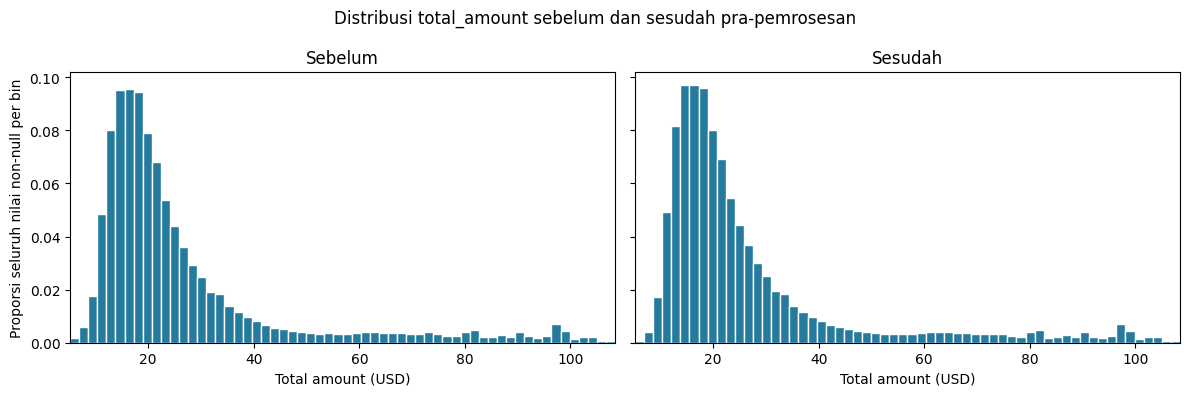

Median berubah dari **20.16 USD** menjadi **20.16 USD**; nilai total ≤0 berkurang dari **25,772** menjadi **0**, karena filter total positif menghapus bagian nonpositif sementara tarif ekstrem positif tetap ditandai.

In [ ]:
sebelum_tarif = mentah_analisis["total_amount"].dropna()
sesudah_tarif = bersih["total_amount"].dropna()
gabungan = pd.concat([sebelum_tarif, sesudah_tarif], ignore_index=True)
xlo, xhi = gabungan.quantile([0.005, 0.995])
bins = np.linspace(xlo, xhi, 61)
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
for a, nilai, judul in zip(ax, [sebelum_tarif, sesudah_tarif], ["Sebelum", "Sesudah"]):
    a.hist(nilai, bins=bins, weights=np.ones(len(nilai))/len(nilai), color="#247b9e", edgecolor="white")
    a.set_title(judul); a.set_xlabel("Total amount (USD)")
    a.set_xlim(xlo, xhi)
    print(judul, "nilai di luar rentang gambar:", int((~nilai.between(xlo, xhi)).sum()))
ax[0].set_ylabel("Proporsi seluruh nilai non-null per bin")
fig.suptitle("Distribusi total_amount sebelum dan sesudah pra-pemrosesan")
fig.tight_layout()
fig.savefig(os.path.join(DIR_SIMPAN, "distribusi_total_amount.png"), dpi=160)
plt.show()
jawaban(f"Median berubah dari **{sebelum_tarif.median():.2f} USD** menjadi "
        f"**{sesudah_tarif.median():.2f} USD**; nilai total ≤0 berkurang dari "
        f"**{int((sebelum_tarif <= 0).sum()):,}** menjadi **{int((sesudah_tarif <= 0).sum()):,}**, "
        "karena filter total positif menghapus bagian nonpositif sementara tarif ekstrem positif tetap ditandai.")
del gabungan


# P. Studi Kasus — Data untuk Tim Penetapan Harga Dinamis

Satu baris per borough asal per jam. Kode agregasi berikut disalin persis dari modul. Meskipun namanya `rata_tarif_per_mil` dan `rata_kecepatan`, keduanya menggunakan **median**, bukan rerata aritmetika. Pembanding hujan merupakan median dari median per jam dengan bobot tiap jam sama, bukan median seluruh perjalanan.


In [ ]:
tabel_analitik = (bersih
    .assign(jam_mulai=bersih["tpep_pickup_datetime"].dt.floor("h"))
    .groupby(["borough_naik", "jam_mulai"], observed=True)
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_tarif_per_mil=("tarif_per_mil", "median"),
         rata_kecepatan=("kecepatan_mph", "median"),
         suhu_c=("suhu_c", "first"), hujan=("hujan", "max"))
    .reset_index())

# Ambang minimum: kelompok yang terlalu kecil tidak bisa disimpulkan
tabel_analitik = tabel_analitik[tabel_analitik["jumlah_perjalanan"] >= 30]

print(tabel_analitik
      .groupby(["borough_naik", "hujan"], observed=True)["rata_tarif_per_mil"]
      .median().unstack())


hujan               0        1
borough_naik                  
Brooklyn       6.9430   7.6550
Manhattan     10.5270  11.4000
Queens         5.4530   5.6365
Unknown        8.7255   9.8860


## P-1. Menyimpan tabel analitik, kamus data, dan lineage

Tabel modul disimpan untuk keterlacakan. Untuk keputusan pricing, versi yang dianalisis di bawah hanya memakai periode Januari 2023, lima borough resmi, dan jam dengan suhu serta hujan terisi. Cuaca hilang tidak dianggap tidak hujan. Kelompok tetap wajib memiliki ≥30 perjalanan. Versi ini disimpan terpisah dari keluaran persis modul.


In [ ]:
tabel_analitik.to_parquet(os.path.join(DIR_SIMPAN, "tabel_analitik_modul.parquet"), index=False)
mask_pricing = (bersih["tpep_pickup_datetime"].ge(pd.Timestamp("2023-01-01")) &
                bersih["tpep_pickup_datetime"].lt(pd.Timestamp("2023-02-01")) &
                bersih["borough_naik"].isin(["Bronx", "Brooklyn", "Manhattan", "Queens", "Staten Island"]) &
                bersih["suhu_c"].notna() & bersih["hujan_mm"].notna())
data_pricing = bersih.loc[mask_pricing].copy()
tabel_pricing = (data_pricing.groupby(["borough_naik", "jam_mulai"], observed=True)
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_tarif_per_mil=("tarif_per_mil", "median"),
         rata_kecepatan=("kecepatan_mph", "median"),
         suhu_c=("suhu_c", "first"), hujan=("hujan", "max"))
    .reset_index())
kelompok_sebelum_ambang = len(tabel_pricing)
tabel_pricing = tabel_pricing.loc[tabel_pricing["jumlah_perjalanan"] >= 30].copy()
assert not tabel_pricing.duplicated(["borough_naik", "jam_mulai"]).any()
tabel_pricing.to_parquet(os.path.join(DIR_SIMPAN, "tabel_analitik.parquet"), index=False)
kamus = """# Kamus Data Tabel Analitik Pricing

Unit pengamatan: satu borough asal per jam waktu lokal America/New_York.
Tabel yang dipakai: tabel_analitik.parquet; tabel_analitik_modul.parquet mempertahankan agregasi asli modul.

| Kolom | Tipe aktual | Satuan | Sumber dan penghitungan | Validitas dan nilai hilang |
|---|---|---|---|---|
"""
definisi = {
    "borough_naik": ("kategori", "Taxi Zone Lookup, join PULocationID ke LocationID", "Lima borough resmi; lokasi tidak diketahui dikecualikan dari pricing"),
    "jam_mulai": ("jam lokal New York", "TLC pickup datetime dibulatkan ke bawah per jam", "Januari 2023; bukan timestamp UTC; nilai kosong dikecualikan"),
    "jumlah_perjalanan": ("perjalanan", "Hitung baris transaksi bersih per borough-jam", "Minimal 30; kunci transaksi dideduplikasi"),
    "rata_tarif_per_mil": ("USD/mil", "Median per kelompok dari total_amount/trip_distance, dibulatkan 3 desimal pada K-9", "Positif; MEDIAN meskipun nama kolom rata; mencakup tip dan biaya dalam total_amount"),
    "rata_kecepatan": ("mil/jam", "Median per kelompok dari trip_distance/(durasi_menit/60), dibulatkan 2 desimal", "Positif; MEDIAN meskipun nama kolom rata"),
    "suhu_c": ("derajat Celsius", "Open-Meteo temperature_2m per jam; nilai first karena cuaca sama per jam", "Cuaca tidak tersedia dikecualikan dari pricing, tanpa imputasi"),
    "hujan": ("biner 0/1", "1 bila precipitation >0,1 mm per jam; max per kelompok", "Hanya jam dengan precipitation tersedia; nilai hilang bukan 0"),
}
for kol, (satuan, sumber, validitas) in definisi.items():
    kamus += f"| {kol} | {tabel_pricing[kol].dtype} | {satuan} | {sumber} | {validitas} |\n"
Path(DIR_SIMPAN, "kamus_data.md").write_text(kamus, encoding="utf-8")
lineage_pricing = {"sumber_trip": URL_TRIP, "sumber_zona": URL_ZONA,
    "sumber_cuaca": API_CUACA, "cuaca_lineage": [r for r in lineage if r["sumber"] == "cuaca"],
    "kolom_kunci_transaksi": KUNCI, "ambang_perjalanan": 30,
    "agregasi": "median tarif_per_mil dan kecepatan_mph per borough-jam",
    "cakupan": "Januari 2023, lima borough, cuaca lengkap",
    "baris_transaksi_sebelum_cakupan": len(bersih), "baris_transaksi_cakupan": len(data_pricing),
    "kelompok_sebelum_ambang": kelompok_sebelum_ambang, "kelompok_akhir": len(tabel_pricing),
    "dibuat_pada": pd.Timestamp.now("UTC").isoformat()}
Path(DIR_SIMPAN, "lineage_pricing.json").write_text(json.dumps(lineage_pricing, ensure_ascii=False, indent=2), encoding="utf-8")
jawaban(f"Versi pricing memakai **{len(data_pricing):,} dari {len(bersih):,} transaksi bersih**. "
        f"Ambang ≥30 perjalanan menyisakan **{len(tabel_pricing):,} dari {kelompok_sebelum_ambang:,} kelompok borough-jam**. "
        "Tabel Parquet, kamus data, dan lineage pricing tersimpan pada DIR_SIMPAN.")
display(tabel_pricing.head())


Versi pricing memakai **2,948,897 dari 2,986,910 transaksi bersih**. Ambang ≥30 perjalanan menyisakan **1,565 dari 3,028 kelompok borough-jam**. Tabel Parquet, kamus data, dan lineage pricing tersimpan pada DIR_SIMPAN.

,borough_naik,jam_mulai,jumlah_perjalanan,rata_tarif_per_mil,rata_kecepatan,suhu_c,hujan
626,Brooklyn,2023-01-01 00:00:00,86,6.9385,14.550,10.9,1
627,Brooklyn,2023-01-01 01:00:00,220,6.9820,13.715,10.6,1
628,Brooklyn,2023-01-01 02:00:00,256,6.6215,15.445,10.6,0
629,Brooklyn,2023-01-01 03:00:00,175,6.6160,16.390,10.5,0
630,Brooklyn,2023-01-01 04:00:00,74,6.9120,14.635,9.8,0


## P-2. Jawaban dugaan hujan meningkatkan tarif per mil

Bandingkan median tarif per mil pada jam hujan dan tidak hujan untuk setiap borough. Selisih positif mendukung dugaan secara deskriptif untuk borough itu; tidak membuktikan kausalitas atau signifikansi statistik. Jumlah jam tiap kondisi ditampilkan agar kelompok dengan dukungan sedikit terlihat.


In [ ]:
pembanding = tabel_pricing.groupby(["borough_naik", "hujan"], observed=True).agg(
    median_tarif_per_mil=("rata_tarif_per_mil", "median"),
    jumlah_jam=("jam_mulai", "size"),
    jumlah_perjalanan=("jumlah_perjalanan", "sum"))
perbandingan_pricing = pembanding["median_tarif_per_mil"].unstack("hujan").reindex(index=["Bronx", "Brooklyn", "Manhattan", "Queens", "Staten Island"], columns=[0, 1])
perbandingan_pricing.columns = ["tidak_hujan_usd_per_mil", "hujan_usd_per_mil"]
perbandingan_pricing["selisih_usd_per_mil"] = perbandingan_pricing["hujan_usd_per_mil"] - perbandingan_pricing["tidak_hujan_usd_per_mil"]
perbandingan_pricing["perubahan_persen"] = 100*perbandingan_pricing["selisih_usd_per_mil"]/perbandingan_pricing["tidak_hujan_usd_per_mil"].replace(0, np.nan)
display(pembanding)
display(perbandingan_pricing)
cuaca_sintetis_dipakai = any(r.get("asal") == "sintetis" for r in lineage if r.get("sumber") == "cuaca")
for borough, r in perbandingan_pricing.iterrows():
    if pd.isna(r["tidak_hujan_usd_per_mil"]) or pd.isna(r["hujan_usd_per_mil"]):
        jawaban(f"**{borough}:** belum dapat dibandingkan karena salah satu kondisi hujan tidak tersedia setelah ambang volume.")
    else:
        kesimpulan = "lebih tinggi" if r["selisih_usd_per_mil"] > 0 else "lebih rendah" if r["selisih_usd_per_mil"] < 0 else "sama"
        jawaban(f"**{borough}:** tidak hujan **{r['tidak_hujan_usd_per_mil']:.3f} USD/mil**, "
                f"hujan **{r['hujan_usd_per_mil']:.3f} USD/mil**; selisih "
                f"**{r['selisih_usd_per_mil']:+.3f} USD/mil ({r['perubahan_persen']:+.2f}%)**. "
                f"Tarif per mil pada jam hujan {kesimpulan} secara deskriptif pada sampel ini.")
if cuaca_sintetis_dipakai:
    jawaban("**Cuaca sintetis dipakai: perbandingan ini hanya demonstrasi pipeline, tidak dapat menguji dugaan hujan nyata.**")
perbandingan_pricing.to_csv(os.path.join(DIR_SIMPAN, "perbandingan_pricing.csv"))
del data_pricing


median_tarif_per_mil  jumlah_jam  jumlah_perjalanan
borough_naik hujan                                                     
Brooklyn     0                    6.9430         125               5585
             1                    7.6550          17                874
Manhattan    0                   10.5270         637            2252553
             1                   11.4000         107             407027
Queens       0                    5.4530         583             228556
             1                    5.6365          96              40641

,tidak_hujan_usd_per_mil,hujan_usd_per_mil,selisih_usd_per_mil,perubahan_persen
borough_naik,,,,
Bronx,NaN,NaN,NaN,NaN
Brooklyn,6.943,7.6550,0.7120,10.254933
Manhattan,10.527,11.4000,0.8730,8.292961
Queens,5.453,5.6365,0.1835,3.365120
Staten Island,NaN,NaN,NaN,NaN


**Bronx:** belum dapat dibandingkan karena salah satu kondisi hujan tidak tersedia setelah ambang volume.

**Brooklyn:** tidak hujan **6.943 USD/mil**, hujan **7.655 USD/mil**; selisih **+0.712 USD/mil (+10.25%)**. Tarif per mil pada jam hujan lebih tinggi secara deskriptif pada sampel ini.

**Manhattan:** tidak hujan **10.527 USD/mil**, hujan **11.400 USD/mil**; selisih **+0.873 USD/mil (+8.29%)**. Tarif per mil pada jam hujan lebih tinggi secara deskriptif pada sampel ini.

**Queens:** tidak hujan **5.453 USD/mil**, hujan **5.636 USD/mil**; selisih **+0.183 USD/mil (+3.37%)**. Tarif per mil pada jam hujan lebih tinggi secara deskriptif pada sampel ini.

**Staten Island:** belum dapat dibandingkan karena salah satu kondisi hujan tidak tersedia setelah ambang volume.

## P-3. Batasan hasil

1. Median dipakai karena distribusi tarif miring. Nama kolom `rata_*` tidak berarti rerata aritmetika, dan median antarjam memberi bobot yang sama pada jam berisi 30 atau ribuan perjalanan.
2. Cuaca diambil untuk satu koordinat New York lalu diterapkan ke seluruh borough. Arsip Open-Meteo memakai data reanalisis; angka tersebut bukan pengukuran hujan pada lokasi tiap kendaraan. Variasi cuaca lokal dapat menyebabkan salah klasifikasi. [Dokumentasi Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api).
3. Korelasi hujan dan tarif bukan sebab-akibat. Jam sibuk, hari, lokasi tujuan, perjalanan bandara, dan panjang perjalanan dapat menjadi faktor perancu; perlu perbandingan terkontrol sebelum menetapkan harga.
4. `tarif_per_mil` menggunakan `total_amount`, sehingga mencakup komponen tip dan biaya, bukan hanya harga dasar. Perjalanan sangat pendek juga dapat menghasilkan rasio tinggi karena biaya tetap.
5. Ambang ≥30 perjalanan menyingkirkan jam sepi, terutama borough dengan volume rendah. Jika salah satu kondisi tidak ada, borough tersebut tidak bisa disimpulkan. Ambang volume bukan jaminan signifikansi statistik.
6. TLC tidak menjamin akurasi data penyedia teknologinya. Deduplikasi berdasarkan kolom terpilih dan filter operasional dapat membuang transaksi yang sah. [Sumber TLC](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page).
7. Analisis ini hanya satu bulan dan lima borough dengan cuaca lengkap. Generalisasi ke musim atau bulan lain belum terbukti; cuaca sintetis, apabila dipakai, hanya layak untuk demonstrasi.


## P-4. Pembaruan otomatis setiap bulan

Parameterkan bulan, unduh file TLC dan cuaca untuk awal sampai akhir bulan tersebut, lalu gunakan pipeline inkremental latihan 6 untuk melewati bulan yang memiliki penanda sukses. Setelah validasi transaksi, hitung ulang fitur tarif per mil, kecepatan, serta hujan, saring cuaca lengkap dan borough resmi, lalu agregasikan per borough-jam dengan ambang 30 perjalanan. Tulis partisi bulan melalui direktori sementara dan penggantian atomik agar rerun tidak menambah duplikasi; simpan checksum sumber, parameter, versi kode, jumlah baris tiap tahap, laporan kualitas, dan lineage bersama keluaran. Scheduler menjalankan proses setelah file bulan tersedia dan memberi pemberitahuan jika unduhan atau validasi gagal. Jika sumber direvisi, versi/checksum baru harus memicu pemrosesan ulang partisi bulan tersebut, sehingga cache tidak dianggap bukti bahwa sumber tidak berubah. Saat mencakup pergantian DST, normalisasikan waktu lokal ke timestamp berzona waktu atau UTC agar dua jam lokal yang namanya sama tidak digabungkan keliru.


# Q. Latihan

Jalankan setelah bagian K. Kode berikut merupakan jawaban latihan, bukan kutipan kode modul.


## Latihan 1 — Kecepatan unduh dan cache

Mengembangkan `unduh_aman` dengan pengukuran MB/detik. Demonstrasi memakai salinan unduhan zona pada path baru: panggilan pertama mengunduh, panggilan kedua membaca cache. Fungsi K-2 asli tetap tersedia dalam sel sebelumnya.


In [ ]:
def unduh_aman(url, tujuan, percobaan=3, jeda_awal=2):
    if os.path.exists(tujuan) and os.path.getsize(tujuan) > 0:
        print("cache ditemukan:", os.path.basename(tujuan))
        return tujuan
    sementara = tujuan + ".part"
    for i in range(percobaan):
        try:
            with requests.get(url, stream=True, timeout=60) as r:
                r.raise_for_status()
                t0 = time.perf_counter()
                with open(sementara, "wb") as f:
                    shutil.copyfileobj(r.raw, f)
                ukuran = os.path.getsize(sementara)
                if ukuran == 0:
                    raise IOError("berkas kosong")
                detik = time.perf_counter() - t0
                os.replace(sementara, tujuan)
                print(f"kecepatan unduh: {ukuran / 1024**2 / max(detik, 1e-9):.3f} MB/detik")
                return tujuan
        except Exception as e:
            jeda = jeda_awal * (2 ** i)
            print(f"percobaan {i+1} gagal ({e}); menunggu {jeda}s")
            time.sleep(jeda)
    raise RuntimeError(f"gagal mengunduh setelah {percobaan} percobaan: {url}")

import tempfile
with tempfile.TemporaryDirectory(dir=DIR_MENTAH) as folder_demo:
    path_demo = os.path.join(folder_demo, "zona_latihan.csv")
    print("Panggilan pertama:")
    unduh_aman(URL_ZONA, path_demo)
    print("Panggilan kedua:")
    unduh_aman(URL_ZONA, path_demo)


Panggilan pertama:
kecepatan unduh: 4.992 MB/detik
Panggilan kedua:
cache ditemukan: zona_latihan.csv


## Latihan 2 — Dua aturan kualitas tambahan

Tip harus terisi dan tidak negatif. Aturan konsistensi mengharuskan total minimal sebesar tarif dasar ditambah tip. Perhitungan memakai ulang data mentah agar persentase sebanding dengan tahap K-6, sebelum imputasi dan deduplikasi.


In [ ]:
trip_latihan = pd.read_parquet(PATH_TRIP, columns=KOLOM)
aturan_tambahan = {
    "validitas: tip_amount ada dan >= 0": (
        trip_latihan["tip_amount"].notna() & (trip_latihan["tip_amount"] >= 0)),
    "konsistensi: total >= fare + tip": (
        trip_latihan["total_amount"] >=
        trip_latihan["fare_amount"] + trip_latihan["tip_amount"]),
}
aturan.update(aturan_tambahan)
laporan_latihan = pd.DataFrame([
    {"aturan": nama, "lulus": int(mask.fillna(False).sum()),
     "gagal": int((~mask.fillna(False)).sum()),
     "persen_gagal": round(100 * (~mask.fillna(False)).mean(), 3)}
    for nama, mask in aturan.items()
]).sort_values("persen_gagal", ascending=False)
display(laporan_latihan)
display(laporan_latihan[laporan_latihan["aturan"].isin(aturan_tambahan)])
del trip_latihan


,aturan,lulus,gagal,persen_gagal
0,kelengkapan: passenger_count ada,2995023,71743,2.339
2,validitas: jarak 0-100 mil,3020816,45950,1.498
5,konsistensi: durasi 1-180 menit,3030383,36383,1.186
3,validitas: total_amount > 0,3040994,25772,0.840
9,konsistensi: total >= fare + tip,3041606,25160,0.820
6,konsistensi: total >= fare,3041743,25023,0.816
8,validitas: tip_amount ada dan >= 0,3066541,225,0.007
7,ketepatan waktu: dalam Jan 2023,3066718,48,0.002
1,keunikan: baris tidak duplikat,3066766,0,0.000
4,validitas: PULocationID dikenal,3066766,0,0.000


,aturan,lulus,gagal,persen_gagal
9,konsistensi: total >= fare + tip,3041606,25160,0.820
8,validitas: tip_amount ada dan >= 0,3066541,225,0.007


## Latihan 3 — Sepuluh pasangan borough tersibuk

Lokasi tujuan digabungkan dengan left join many-to-one. Jumlah baris wajib tetap. Kelompok tanpa borough tetap dihitung dengan `dropna=False` agar cakupan data terlihat.


In [ ]:
zona_tujuan = zona[["LocationID", "Borough", "Zone"]].rename(columns={
    "LocationID": "DOLocationID", "Borough": "borough_turun", "Zone": "zona_turun"})
bersih_tujuan = bersih.merge(zona_tujuan, on="DOLocationID",
                             how="left", validate="many_to_one")
assert len(bersih_tujuan) == len(bersih)
pasangan_tersibuk = (bersih_tujuan
    .groupby(["borough_naik", "borough_turun"], dropna=False, observed=True)
    .size().rename("jumlah_perjalanan").reset_index()
    .sort_values(["jumlah_perjalanan", "borough_naik", "borough_turun"],
                 ascending=[False, True, True]).head(10))
print("tujuan tanpa borough:", bersih_tujuan["borough_turun"].isna().sum())
display(pasangan_tersibuk)


tujuan tanpa borough: 9511


,borough_naik,borough_turun,jumlah_perjalanan
25,Manhattan,Manhattan,2491566
33,Queens,Manhattan,155261
26,Manhattan,Queens,82354
23,Manhattan,Brooklyn,62986
34,Queens,Queens,59146
31,Queens,Brooklyn,42187
48,Unknown,Manhattan,18432
51,Unknown,Unknown,13562
22,Manhattan,Bronx,8865
9,Brooklyn,Brooklyn,7910


## Latihan 4 — MinMaxScaler dibanding StandardScaler

MinMaxScaler dipasang hanya pada data latih yang sama dengan K-9. Data latih berada pada rentang 0–1 (fitur konstan menjadi 0); data uji dapat keluar dari rentang tersebut. StandardScaler memusatkan rerata dan menyesuaikan simpangan baku, tanpa batas rentang tetap. Perbedaan ini penting bagi KNN, K-means, SVM, PCA, dan jaringan saraf karena skala memengaruhi jarak atau optimisasi. Pohon keputusan dan random forest umumnya tidak membutuhkan scaling.


In [ ]:
from sklearn.preprocessing import MinMaxScaler
skala_minmax = MinMaxScaler().fit(latih[FITUR_NUM])
latih_minmax = skala_minmax.transform(latih[FITUR_NUM])
uji_minmax = skala_minmax.transform(uji[FITUR_NUM])
rentang = []
for metode, bagian, nilai in [
    ("StandardScaler", "latih", latih_num),
    ("StandardScaler", "uji", uji_num),
    ("MinMaxScaler", "latih", latih_minmax),
    ("MinMaxScaler", "uji", uji_minmax),
]:
    for i, fitur in enumerate(FITUR_NUM):
        rentang.append({"metode": metode, "data": bagian, "fitur": fitur,
                        "min": nilai[:, i].min(), "max": nilai[:, i].max()})
display(pd.DataFrame(rentang))


,metode,data,fitur,min,max
0,StandardScaler,latih,trip_distance_capped,-0.793948,4.246792
1,StandardScaler,latih,durasi_menit,-1.225975,13.924810
2,StandardScaler,latih,suhu_c,-2.288100,3.347487
3,StandardScaler,uji,trip_distance_capped,-0.793948,4.246792
4,StandardScaler,uji,durasi_menit,-1.225975,12.557052
5,StandardScaler,uji,suhu_c,-2.288100,3.347487
6,MinMaxScaler,latih,trip_distance_capped,0.000000,1.000000
7,MinMaxScaler,latih,durasi_menit,0.000000,1.000000
8,MinMaxScaler,latih,suhu_c,0.000000,1.000000
9,MinMaxScaler,uji,trip_distance_capped,0.000000,1.000000


## Latihan 5 — Pembuktian validasi many-to-one

Satu baris zona digandakan pada salinan khusus. Join harus menghasilkan MergeError. Tabel zona asli tidak dimutasi dan diperiksa tetap sama setelah demonstrasi.


In [ ]:
zona_sebelum = zona.copy(deep=True)
zona_ganda = pd.concat([zona, zona.iloc[[0]]], ignore_index=True)
try:
    bersih[["PULocationID"]].merge(
        zona_ganda[["LocationID", "Borough"]],
        left_on="PULocationID", right_on="LocationID",
        how="left", validate="many_to_one")
except pd.errors.MergeError as e:
    print(type(e).__name__ + ":", str(e))
else:
    raise AssertionError("Join seharusnya ditolak karena kunci kanan ganda")
finally:
    del zona_ganda
pd.testing.assert_frame_equal(zona, zona_sebelum)
print("Tabel zona kembali pada keadaan semula:", zona["LocationID"].is_unique)


MergeError: Merge keys are not unique in right dataset; not a many-to-one merge
Tabel zona kembali pada keadaan semula: True


## Latihan 6 — Pipeline bulanan inkremental

Bulan memakai format YYYY-MM. Setiap bulan memiliki direktori sendiri dan penanda selesai yang ditulis setelah Parquet berhasil tersimpan. Direktori sementara diganti secara atomik; bulan yang sudah selesai dilewati sebelum mengunduh atau memproses data. Cuaca diambil sesuai bulan, tanggal trip dibatasi pada bulan tersebut. Dua pemanggilan dibandingkan berdasarkan nama, ukuran, dan waktu modifikasi seluruh berkas untuk membuktikan tidak ada berkas baru atau penulisan ulang.


In [ ]:
from pathlib import Path
import re
DIR_INKREMENTAL = Path(DIR_KURASI) / "trips_inkremental"

def pipeline_inkremental(bulan):
    if not re.fullmatch(r"\d{4}-\d{2}", bulan):
        raise ValueError("Gunakan format YYYY-MM")
    mulai = pd.Timestamp(bulan + "-01")
    akhir = mulai + pd.offsets.MonthBegin(1)
    DIR_INKREMENTAL.mkdir(parents=True, exist_ok=True)
    tujuan = DIR_INKREMENTAL / f"bulan={bulan}"
    if (tujuan / "_SUCCESS.json").is_file():
        print("Bulan sudah diproses; dilewati:", bulan)
        return str(tujuan)
    if tujuan.exists():
        raise RuntimeError(f"Direktori belum lengkap: {tujuan}")
    url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{bulan}.parquet"
    path_trip = os.path.join(DIR_MENTAH, f"yellow_tripdata_{bulan}.parquet")
    unduh_aman(url, path_trip)
    unduh_aman(URL_ZONA, PATH_ZONA)
    df_cuaca = ambil_cuaca(mulai.strftime("%Y-%m-%d"),
                          (akhir - pd.Timedelta(days=1)).strftime("%Y-%m-%d"))
    df_cuaca = df_cuaca.rename(columns={"time": "jam_mulai",
        "temperature_2m": "suhu_c", "precipitation": "hujan_mm"})
    df_cuaca["jam_mulai"] = pd.to_datetime(df_cuaca["jam_mulai"])
    df = pipeline(path_trip, PATH_ZONA, df_cuaca, tarif_referensi)
    df = df.loc[(df["tpep_pickup_datetime"] >= mulai) &
                (df["tpep_pickup_datetime"] < akhir)].copy()
    validasi(df)
    with tempfile.TemporaryDirectory(prefix=f".proses-{bulan}-",
                                     dir=DIR_INKREMENTAL) as folder:
        sementara = Path(folder) / "hasil"
        df.to_parquet(sementara, partition_cols=["borough_naik"], index=False)
        (sementara / "_SUCCESS.json").write_text(json.dumps({
            "bulan": bulan, "baris": len(df), "sumber_trip": url,
            "sumber_cuaca": API_CUACA,
            "selesai_pada": pd.Timestamp.now("UTC").isoformat()
        }, ensure_ascii=False, indent=2), encoding="utf-8")
        os.replace(sementara, tujuan)
    catat_sumber(f"trip_{bulan}", url, len(df), "pipeline inkremental selesai")
    print("Bulan selesai:", bulan, "| baris:", len(df))
    return str(tujuan)

def inventaris_inkremental():
    return {str(p.relative_to(DIR_INKREMENTAL)):
            (p.stat().st_size, p.stat().st_mtime_ns)
            for p in DIR_INKREMENTAL.rglob("*") if p.is_file()}

pipeline_inkremental("2023-01")
berkas_pertama = inventaris_inkremental()
pipeline_inkremental("2023-01")
berkas_kedua = inventaris_inkremental()
assert berkas_pertama == berkas_kedua
print("Idempoten:", berkas_pertama == berkas_kedua)
print("Berkas baru pada panggilan kedua:",
      len(set(berkas_kedua) - set(berkas_pertama)))


cache ditemukan: yellow_tripdata_2023-01.parquet
cache ditemukan: taxi_zone_lookup.csv
Validasi lulus: 2,986,910 baris x 17 kolom
Validasi lulus: 2,986,873 baris x 17 kolom
[lineage] trip_2023-01: 2,986,873 baris
Bulan selesai: 2023-01 | baris: 2986873
Bulan sudah diproses; dilewati: 2023-01
Idempoten: True
Berkas baru pada panggilan kedua: 0


# S. Pertanyaan Evaluasi

Jawaban konseptual berikut ditempatkan langsung sebagai sel Markdown di notebook.


## S-1. ETL dan ELT

ETL berarti Extract → Transform → Load: data ditransformasikan sebelum dimuat ke penyimpanan tujuan. ELT berarti Extract → Load → Transform: data mentah dimuat dahulu, lalu ditransformasikan dengan sumber daya sistem tujuan. ELT lazim pada Big Data karena penyimpanan relatif murah dan komputasi data lake/warehouse dapat diskalakan. Data mentah tetap tersedia untuk audit serta pemrosesan ulang ketika kebutuhan atau skema berubah. Pemilihannya tetap bergantung pada kebutuhan privasi, biaya, dan kemampuan sistem.


## S-2. Risiko akuisisi API

Tiga risiko utama: **rate limit**, ditangani dengan jeda, batas permintaan, dan mengikuti `Retry-After`; **gangguan jaringan/server**, ditangani dengan timeout serta retry terbatas memakai exponential backoff; **perubahan skema atau respons tidak lengkap**, ditangani dengan validasi struktur, tipe, kelengkapan, dan pencatatan versi/respons mentah. Modul mencoba ulang HTTP 429, 500, 502, dan 503; pada GET yang idempoten, timeout dan 504 juga dapat dicoba ulang secara terbatas. HTTP 400, 401, 403, dan 404 umumnya perlu perbaikan permintaan, izin, atau URL, sehingga tidak diulang begitu saja. Tidak semua 5xx selalu bisa pulih; gunakan kebijakan layanan dan batas percobaan.


## S-3. MCAR, MAR, dan MNAR

**MCAR**: hilangnya nilai tidak bergantung pada variabel teramati maupun nilainya sendiri, misalnya sebagian catatan hilang akibat gangguan acak. **MAR**: setelah mengondisikan variabel teramati, kehilangan tidak lagi bergantung pada nilai yang hilang; contohnya jumlah penumpang lebih sering tidak tercatat pada jam tertentu. **MNAR**: kehilangan masih bergantung pada nilai yang tidak teramati, misalnya tarif sangat besar sengaja tidak dicatat. Mengisi tarif MNAR dengan median akan membuat transaksi mahal terlihat biasa dan dapat meremehkan pendapatan serta risiko. Sebaiknya tandai kehilangan, selidiki proses sumber, dan lakukan analisis sensitivitas; mekanismenya tidak dapat dipastikan hanya dari pola data yang terlihat.


## S-4. Z-score pada distribusi miring

Z-score memakai rerata dan simpangan baku. Pada distribusi miring ke kanan, nilai besar menggeser rerata dan memperbesar simpangan baku, sehingga aturan |z| > 3 dapat melewatkan sebagian nilai ekstrem dan tidak memiliki interpretasi normal yang sama. IQR lebih sesuai sebagai penanda awal karena menggunakan kuartil yang lebih tahan terhadap ekor panjang. Namun IQR juga dapat menandai nilai sah pada distribusi miring; gunakan aturan bisnis, penandaan, atau transformasi log bila sesuai, bukan langsung menghapus semua outlier.


## S-5. Join dengan kunci referensi ganda

Satu baris transaksi dapat memperoleh beberapa pasangan pada tabel referensi, sehingga jumlah baris dan agregat dapat membengkak. Pencegahan pertama adalah memeriksa `LocationID.is_unique` atau `duplicated()` lalu menyelesaikan referensi ganda sesuai aturan sumber, bukan membuangnya sembarangan. Pencegahan kedua adalah memakai `merge(validate="many_to_one")` sehingga pandas menghentikan join dengan MergeError ketika kunci kanan tidak unik. Catat juga jumlah baris sebelum dan sesudah join.


## S-6. Data leakage saat scaling

Kebocoran terjadi bila statistik scaler dipelajari dari data yang mencakup data uji, sehingga informasi data uji ikut memengaruhi transformasi dan evaluasi tidak lagi sepenuhnya independen. Urutan benar: pisahkan data latih/uji; `fit` scaler dan imputer hanya pada latih; `transform` latih dan uji memakai parameter yang sama; latih model pada latih; evaluasi pada uji. Pada cross-validation, seluruh preprocessing dipasang ulang di bagian latih setiap fold, misalnya melalui Pipeline. [Dokumentasi scikit-learn](https://scikit-learn.org/1.5/common_pitfalls.html).


## S-7. Idempotensi pipeline

Pipeline idempoten menghasilkan keadaan akhir yang sama jika dijalankan ulang dengan sumber, parameter, dan versi kode yang sama. Teknik pertama: tulis keluaran per bulan secara overwrite/replace atomik, bukan append tanpa kontrol, dan gunakan penanda sukses untuk melewati partisi yang sudah lengkap. Teknik kedua: gunakan kunci deterministik dan deduplikasi atau upsert sehingga pemrosesan ulang tidak menambah transaksi ganda. Kesamaan jumlah baris saja belum membuktikan idempotensi isi; bandingkan kunci, nilai, checksum, atau inventaris berkas. Bila sumber berubah, hasil dapat berubah dan harus dicatat sebagai versi baru.


## S-8. Kerugian partisi berkardinalitas tinggi

Kolom dengan banyak nilai unik dapat menghasilkan banyak direktori dan berkas kecil. Overhead metadata, listing direktori, pembukaan berkas, dan penjadwalan tugas dapat lebih besar daripada waktu membaca data. Gejalanya berupa ribuan berkas kecil, proses tulis/baca lambat, dan tugas Spark kecil yang terlalu banyak. Pilih partisi yang sesuai pola filter dan volume per partisi, misalnya bulan dan borough, lalu kendalikan jumlah serta ukuran berkas. Broadcast mengurangi biaya shuffle join tabel kecil, tetapi tidak menyelesaikan masalah berkas kecil. [Dokumentasi Spark](https://spark.apache.org/docs/3.5.5/sql-performance-tuning.html).


## S-9. Pemeriksaan sebelum scraping ulasan

Empat hal yang diperiksa: (1) ketentuan penggunaan, lisensi, dan apakah API atau izin resmi tersedia; (2) `robots.txt`, batas laju, serta instruksi pemilik layanan; (3) data pribadi/sensitif, kebutuhan minimisasi, anonimisasi, dasar pemrosesan, dan aturan yang berlaku di yurisdiksi terkait; (4) keamanan penyimpanan, tujuan penelitian, hak penggunaan ulang, serta beban akses pada server. `robots.txt` bukan izin akses dan bukan pengganti ketentuan hukum. Saya menolak bila pengambilan mensyaratkan membobol autentikasi atau mengakses ulasan privat tanpa kewenangan; cari data berizin sebagai alternatif. [RFC 9309](https://www.rfc-editor.org/rfc/rfc9309.html), [Prinsip privasi OECD](https://www.oecd.org/en/topics/privacy-principles.html).
